# Bayesian analysis on São Paulo data

This notebook is based on a open BUGS code developed by my professor, the goal of this is to generate better graphs than the ones from BUGS.

In [9]:
#Import libraries 

import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Libraries used to retrieve data from Google Drive
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive

In [3]:
#Retrieve data from Google Drive

#Set authentification and drive
auth= GoogleAuth()
#auth.LocalWebserverAuth()
drive= GoogleDrive(auth)

#Extract datase from Google Drive
file= drive.ListFile({'q': "title= 'dados_por_municipio_2019-2024.xlsx' and trashed=false"}).GetList()
for file_ in file:
    print('Title: %s, id= %s' % (file_['title'], file_['id']))

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?client_id=1036185829078-4ehal5k5u105gjb9i95beo69q33l9n33.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8080%2F&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive&access_type=offline&response_type=code

Authentication successful.
Title: dados_por_municipio_2019-2024.xlsx, id= 1KzUU97RFlJv-tEpdz16a8hRxyFOQZ7NI


In [5]:
#Create the dataframe

#Get the id and create the file to convert it later on a dataframe
id = file[0]['id']
file_= drive.CreateFile({'id':id})
file_.GetContentFile('dados_por_municipio_2019-2024.xlsx')

#Convert excel to pd dataframe
df= pd.read_excel('dados_por_municipio_2019-2024.xlsx')
#Print the first row
df.head(1)

,municipio SP,fatal,grave,leve,não dispon,total,ano,pop 2021,total/pop,fatal/total,...,logit(leve/total),PIB/100000,PIB.cap/1000,Unnamed: 26,Unnamed: 27,fatal/total_1,grave/total_1,leve/total_1,nao disp/total,unreported/total
0,Adamantina,0,10,235,47,292,2019,35153,0.008307,0.0,...,1.416534,13.70865,38.997098,NaN,NaN,0.0,0.034247,0.804795,0.160959,0.160959


In [7]:
#Drop empty columns
for i in df.columns:
    if i[0:7] in 'Unnamed':
        df = df.drop(labels=[i], axis= 1)
df.columns

Index(['municipio SP', 'fatal', 'grave', 'leve', 'não dispon', 'total', 'ano',
       'pop 2021', 'total/pop', 'fatal/total', 'grave/total', 'leve/total',
       'IDH municipal', 'IDH renda', 'IDH longevidade', 'IDH educação',
       'PIB municipal em milhares -2020', 'PIB per capita', 'area km**2',
       'dens dem 2021', 'logit(total/pop)', 'logit(fatal/total)',
       'logit(grave/total)', 'logit(leve/total)', 'PIB/100000', 'PIB.cap/1000',
       'fatal/total_1', 'grave/total_1', 'leve/total_1', 'nao disp/total',
       'unreported/total'],
      dtype='object')

# Checking Multicollinearity

### Variance Inflation Factor (VIF)

In [78]:
#Let's create the function to apply VIF

#Import library
from sklearn.linear_model import LinearRegression

#Define the function
def calculate_vif(data, features):
    vif, tolerance= {},{}
    #Extract all the relevant features
    for feature in features:
        #Retrieve the relevant features
        X= [f for f in features if f != feature]

        #X contains all the predictors except one, y contains that predictor to be regressed against
        X,y= data[X], data[feature]

        #R2
        r2= LinearRegression().fit(X,y).score(X,y)

        #Tolerance 
        tolerance[feature] = 1 - r2

        #VIF
        vif[feature]= 1/1-tolerance[feature]
    #Return
    return pd.DataFrame({'VIF': vif, 'Tolerance': tolerance})

In [85]:
#Calculating VIF
calculate_vif(data=df, features=df[['total/pop', 'ano', 'IDH municipal', 'PIB per capita', 'area km**2', 'dens dem 2021']])

,VIF,Tolerance
total/pop,0.140585,0.859415
ano,0.006798,0.993202
IDH municipal,0.184680,0.815320
PIB per capita,0.071206,0.928794
area km**2,0.065055,0.934945
dens dem 2021,0.096713,0.903287


Function show no correlation among the features/covariates.

# Bayesian Beta Regression

## Beta Regression with priors following U(a=-1,b=1)

In [11]:
#Define covariates and convert data into np.array
N = len(df)
y = df['total/pop'].to_numpy()
year = df.ano.to_numpy()
idh = df['IDH municipal'].to_numpy()
pib_cap = df['PIB per capita'].to_numpy()
area = np.array(df['area km**2'])
dens_dem = df['dens dem 2021'].to_numpy()

In [29]:
#Bayesian Beta Regression
with pm.Model() as beta_regression_model:

    #Priors for regression coefficients
    beta1 = pm.Uniform('beta1', lower = -1, upper = 1)  #Year effect
    beta2 = pm.Uniform('beta2', lower = -1, upper = 1)  #IDH effect
    beta3 = pm.Uniform('beta3', lower = -1, upper = 1)  #log(PIB_cap) effect
    beta4 = pm.Uniform('beta4', lower = -1, upper = 1)  #log(area) effect
    beta5 = pm.Uniform('beta5', lower = -1, upper = 1)  #log(dens_dem) effect

    #Precission parameter for Beta distribution (phi)
    phi = pm.Uniform('phi', lower = 0, upper = 1000)  

    #Random effect precission
    tau = pm.Uniform('tau', lower = 0, upper = 10000)

    #Non-centered random effects (key change)
    #tau = pm.HalfNormal("tau", 1)
    #beta0_raw = pm.Normal("beta0_raw", 0, 1, shape=N)
    #beta0 = beta0_raw * tau 

    #Random intercepts for each observation/municipality
    sigma = pm.Deterministic('sigma', 1.0/pm.math.sqrt(tau))
    beta0 = pm.Normal("beta0", mu=0, sigma=sigma, shape=N)
    
    #Standarizing Density
    dens_dem_std = (np.log(dens_dem) - np.log(dens_dem).mean()) / np.log(dens_dem).std()

    #Linear predictor on logit scale
    logit_mu = (beta0 + beta1 * (year - 2018) + beta2 * idh + beta3 * np.log(pib_cap) + beta4 * np.log(area) + beta5 * np.log(dens_dem))

    mu = pm.Deterministic('mu', pm.math.invlogit(logit_mu))

    #Beta distribution reparametrized: a = phi*mu, b = phi*(1-mu)
    alpha = pm.Deterministic('alpha', phi * mu)
    beta = pm.Deterministic('beta_param', phi * (1 - mu))
    #alpha =  phi * mu
    #beta  =  phi * (1 - mu)

    #Likelihood
    y_obs = pm.Beta('y_obs', alpha=alpha, beta=beta, observed=y)

    #Sampling
    #trace = pm.sample(2000, tune= 1000, target_acceptance=0.95, return_inferencedata=True, idata_kwargs={"log_likelihood": True}) 
    trace = pm.sample(2000, tune= 3000, target_acceptance=0.99, chains=4, cores=4, return_inferencedata=True, idata_kwargs={"log_likelihood": True}) 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta1, beta2, beta3, beta4, beta5, phi, tau, beta0]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 169 seconds.


#### Summary Table

In [32]:
#Print summary
az.summary(trace, var_names=["beta1", "beta2", "beta3", "beta4", "beta5", "phi", "tau"], hdi_prob= 0.9) #AQUIIII

,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta1,-0.000,0.006,-0.011,0.010,0.000,0.000,10440.0,6372.0,1.0
beta2,-0.983,0.016,-1.000,-0.962,0.000,0.000,9438.0,3845.0,1.0
beta3,-0.519,0.010,-0.535,-0.503,0.000,0.000,7911.0,6410.0,1.0
beta4,0.043,0.014,0.021,0.067,0.000,0.000,7908.0,6690.0,1.0
beta5,0.038,0.008,0.025,0.051,0.000,0.000,8403.0,6501.0,1.0
phi,990.731,8.957,978.690,1000.000,0.105,0.075,5310.0,3467.0,1.0
tau,7.011,0.460,6.241,7.740,0.014,0.010,1041.0,1698.0,1.0


We can observe that all covariates and parameters converged well and also we have some covariates having significant impact over the outcome variable, but the big problem with this outcome is Beta2. </br>
Beta2 creadible interval is hitting the boundary, making this model statistically invalid for that coefficient.

#### Trace Plot

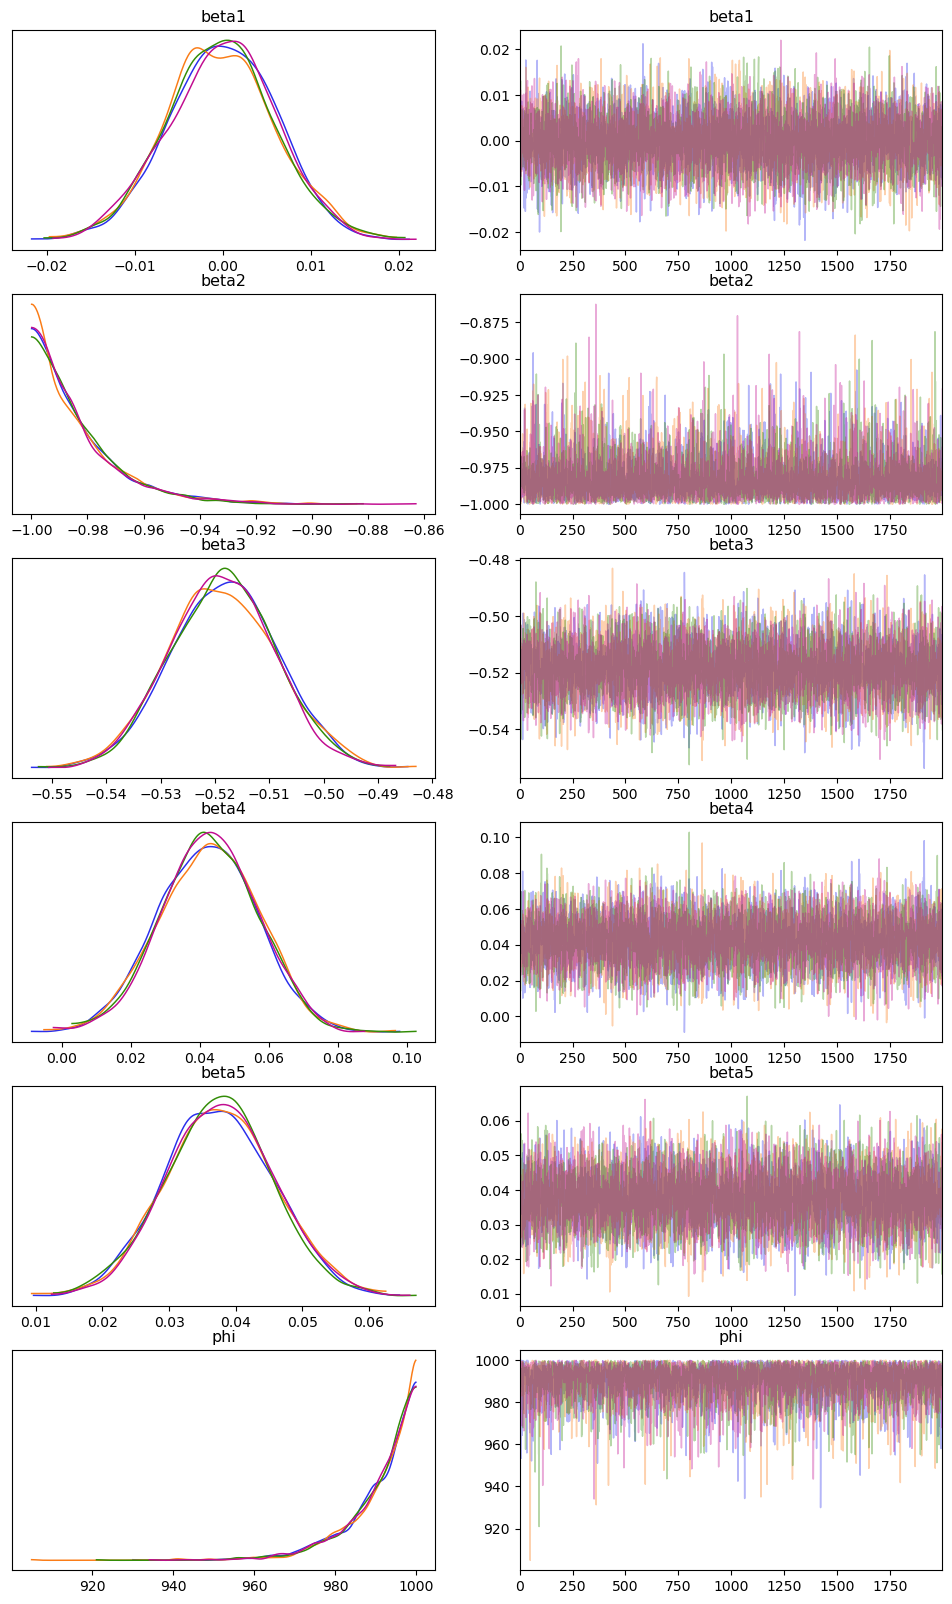

In [114]:
# Posterior plots
az.plot_trace(trace, var_names=["beta1", "beta2", "beta3", "beta4", "beta5", "phi"], compact=False, figsize=(12,20))
plt.savefig('ModelWithUniformDist.jpg', dpi=600)

#### Forest Plot

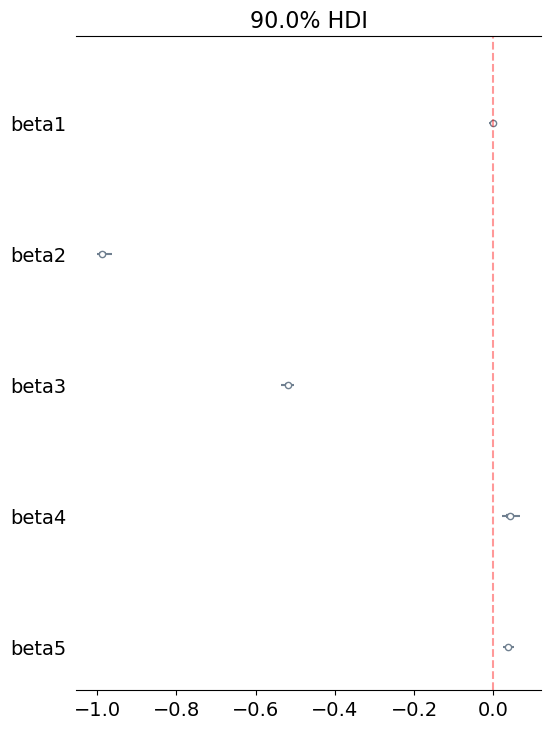

In [117]:
#Forest plot
az.plot_forest(trace, combined=True, colors= 'slategray', var_names= ["beta1", "beta2", "beta3", "beta4", "beta5"], hdi_prob=0.90)
plt.axvline(x=0, c='red', linestyle='--', alpha=0.4)
plt.savefig('ForestplotModelWithUniformDist.jpg', dpi=600)

## Beta Regression with priors following Normal(μ=0, σ=1)

This section is dedicated to try different distributions for the priors, precission parameter and random effect. </br>
All the priors are going to have a weakly informative normal distribution with μ = 0 and 𝛔 = 1. </br>
Phi and Tau are going to have a half normal distribution because both might have a positive sign.

In [494]:
#Bayesian Beta Regression
with pm.Model() as beta_regression_model_trial:

    #Priors for regression coefficients
    beta1 = pm.Normal('beta1', mu = 0, sigma = 1)  #Year effect
    beta2 = pm.Normal('beta2', mu = 0, sigma = 1)  #IDH effect
    beta3 = pm.Normal('beta3', mu = 0, sigma = 1)  #log(PIB_cap) effect
    beta4 = pm.Normal('beta4', mu = 0, sigma = 1)  #log(area) effect
    beta5 = pm.Normal('beta5', mu = 0, sigma = 1)  #log(dens_dem) effect

    #Precission parameter for Beta distribution (phi)
    phi = pm.HalfNormal('phi', sigma = 100)  

    #Random effect precission
    tau = pm.HalfNormal('tau', sigma = 100)

    #Non-centered random effects (key change)
    #tau = pm.HalfNormal("tau", 1)
    #beta0_raw = pm.Normal("beta0_raw", 0, 1, shape=N)
    #beta0 = beta0_raw * tau 

    #Random intercepts for each observation/municipality
    sigma = pm.Deterministic('sigma', 1.0/pm.math.sqrt(tau))
    beta0 = pm.Normal("beta0", mu=0, sigma=sigma, shape=N)
    
    #Standarizing Density
    dens_dem_std = (np.log(dens_dem) - np.log(dens_dem).mean()) / np.log(dens_dem).std()

    #Linear predictor on logit scale
    logit_mu = (beta0 + beta1 * (year - 2018) + beta2 * idh + beta3 * np.log(pib_cap) + beta4 * np.log(area) + beta5 * dens_dem_std)# np.log(dens_dem))

    mu = pm.Deterministic('mu', pm.math.invlogit(logit_mu))

    #Beta distribution reparametrized: a = phi*mu, b = phi*(1-mu)
    alpha = pm.Deterministic('alpha', phi * mu)
    beta = pm.Deterministic('beta_param', phi * (1 - mu))
    #alpha =  phi * mu
    #beta  =  phi * (1 - mu)

    #Likelihood
    y_obs = pm.Beta('y_obs', alpha=alpha, beta=beta, observed=y)

    #Sampling
    #trace = pm.sample(2000, tune= 1000, target_acceptance=0.95, return_inferencedata=True, idata_kwargs={"log_likelihood": True}) 
    trace_trial = pm.sample(2000, tune= 2000, target_acceptance=0.99, return_inferencedata=True, idata_kwargs={"log_likelihood": True}) # chains=4, cores=4

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta1, beta2, beta3, beta4, beta5, phi, tau, beta0]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 266 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [498]:
# Summary statistics
az.summary(trace_trial, var_names=["beta1", "beta2", "beta3", "beta4", "beta5", "phi", "tau"], hdi_prob= 0.9)

,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta1,0.009,0.006,-0.000,0.019,0.000,0.000,11872.0,6673.0,1.00
beta2,-6.010,0.263,-6.430,-5.565,0.003,0.002,6993.0,5585.0,1.00
beta3,-0.195,0.019,-0.228,-0.167,0.000,0.000,6355.0,6110.0,1.00
beta4,0.127,0.013,0.106,0.149,0.000,0.000,9336.0,6780.0,1.00
beta5,0.181,0.011,0.162,0.199,0.000,0.000,9231.0,6652.0,1.00
phi,976.640,54.516,889.058,1067.653,3.652,2.586,217.0,338.0,1.03
tau,10.748,1.957,7.708,13.686,0.163,0.118,163.0,168.0,1.03


We can observer that the outcomes are similar to the last model with the priors set to U(-1,1). The only problem are Phi and Tau having a r_hat greater than 1.01. Let's see the posterior of these two parameter and then change their distributions.

In [123]:
az.plot_posterior(trace_trial, var_names=["phi", "tau"])
plt.savefig('PosteriorPhiTau.jpg', dpi=600)

NameError: name 'trace_trial' is not defined

We can see that phi follows a unimodal normal distribution with positive values while tau is not symmetric, it's right skewed due to the long tail to the right.</br>

Lets change the distribution of Phi and Tau to a Half Normal distribution.

### Phi and Tau following a Half Normal distribution

In [506]:
#Bayesian Beta Regression
with pm.Model() as beta_regression_model_phi:

    #Priors for regression coefficients
    beta1 = pm.Normal('beta1', mu = 0, sigma = 1)  #Year effect
    beta2 = pm.Normal('beta2', mu = 0, sigma = 1)  #IDH effect
    beta3 = pm.Normal('beta3', mu = 0, sigma = 1)  #log(PIB_cap) effect
    beta4 = pm.Normal('beta4', mu = 0, sigma = 1)  #log(area) effect
    beta5 = pm.Normal('beta5', mu = 0, sigma = 1)  #log(dens_dem) effect

    #Precission parameter for Beta distribution (phi)
    phi = pm.HalfNormal('phi', sigma = 10)  

    #Random effect precission
    tau = pm.HalfNormal('tau', sigma = 100)

    #Non-centered random effects (key change)
    #tau = pm.HalfNormal("tau", 1)
    #beta0_raw = pm.Normal("beta0_raw", 0, 1, shape=N)
    #beta0 = beta0_raw * tau 

    #Random intercepts for each observation/municipality
    sigma = pm.Deterministic('sigma', 1.0/pm.math.sqrt(tau))
    beta0 = pm.Normal("beta0", mu=0, sigma=sigma, shape=N)
    
    #Standarizing Density
    dens_dem_std = (np.log(dens_dem) - np.log(dens_dem).mean()) / np.log(dens_dem).std()

    #Linear predictor on logit scale
    logit_mu = (beta0 + beta1 * (year - 2018) + beta2 * idh + beta3 * np.log(pib_cap) + beta4 * np.log(area) + beta5 * dens_dem_std)# np.log(dens_dem))

    mu = pm.Deterministic('mu', pm.math.invlogit(logit_mu))

    #Beta distribution reparametrized: a = phi*mu, b = phi*(1-mu)
    alpha = pm.Deterministic('alpha', phi * mu)
    beta = pm.Deterministic('beta_param', phi * (1 - mu))
    #alpha =  phi * mu
    #beta  =  phi * (1 - mu)

    #Likelihood
    y_obs = pm.Beta('y_obs', alpha=alpha, beta=beta, observed=y)

    #Sampling
    #trace = pm.sample(2000, tune= 1000, target_acceptance=0.95, return_inferencedata=True, idata_kwargs={"log_likelihood": True}) 
    trace_phi = pm.sample(2000, tune= 2000, target_acceptance=0.99, return_inferencedata=True, idata_kwargs={"log_likelihood": True}) # chains=4, cores=4

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta1, beta2, beta3, beta4, beta5, phi, tau, beta0]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 169 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [508]:
az.summary(trace_phi, var_names=["beta1", "beta2", "beta3", "beta4", "beta5", "phi", "tau"], hdi_prob= 0.9)

,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta1,0.007,0.007,-0.004,0.018,0.000,0.000,9851.0,6323.0,1.00
beta2,-5.714,0.304,-6.204,-5.210,0.005,0.003,4302.0,4940.0,1.00
beta3,-0.175,0.022,-0.211,-0.140,0.000,0.000,4360.0,5567.0,1.00
beta4,0.096,0.016,0.069,0.121,0.000,0.000,6718.0,6439.0,1.00
beta5,0.157,0.013,0.135,0.178,0.000,0.000,6882.0,6344.0,1.00
phi,312.031,6.139,302.443,322.460,0.065,0.046,9016.0,6001.0,1.00
tau,263.950,53.942,175.497,341.015,6.109,4.336,81.0,155.0,1.03


Phi got a better result using a Half Normal distribution, but tau remains the same. Let's try to chang Tau distribution to an Exponential.

### Tau following an Exponential distribution (Final Model)

In [13]:
#Beta model with a different tau

#Bayesian Beta Regression
with pm.Model() as beta_regression_:

    #Priors for regression coefficients
    beta1 = pm.Normal('beta1', mu = 0, sigma = 1)  #Year effect
    beta2 = pm.Normal('beta2', mu = 0, sigma = 1)  #IDH effect
    beta3 = pm.Normal('beta3', mu = 0, sigma = 1)  #log(PIB_cap) effect
    beta4 = pm.Normal('beta4', mu = 0, sigma = 1)  #log(area) effect
    beta5 = pm.Normal('beta5', mu = 0, sigma = 1)  #log(dens_dem) effect

    #Precission parameter for Beta distribution (phi)
    phi = pm.HalfNormal('phi', sigma = 10)  

    #Random effect precission
    tau = pm.Exponential('tau', lam=0.1)

    #Non-centered random effects (key change)
    #tau = pm.HalfNormal("tau", 1)
    #beta0_raw = pm.Normal("beta0_raw", 0, 1, shape=N)
    #beta0 = beta0_raw * tau 

    #Random intercepts for each observation/municipality
    sigma = pm.Deterministic('sigma', 1.0/pm.math.sqrt(tau))
    beta0 = pm.Normal("beta0", mu=0, sigma=sigma, shape=N)
    
    #Standarizing Density
    dens_dem_std = (np.log(dens_dem) - np.log(dens_dem).mean()) / np.log(dens_dem).std()

    #Linear predictor on logit scale
    logit_mu = (beta0 + beta1 * (year - 2018) + beta2 * idh + beta3 * np.log(pib_cap) + beta4 * np.log(area) + beta5 * dens_dem_std)# np.log(dens_dem))

    mu = pm.Deterministic('mu', pm.math.invlogit(logit_mu))

    #Beta distribution reparametrized: a = phi*mu, b = phi*(1-mu)
    alpha = pm.Deterministic('alpha', phi * mu)
    beta = pm.Deterministic('beta_param', phi * (1 - mu))
    #alpha =  phi * mu
    #beta  =  phi * (1 - mu)

    #Likelihood
    y_obs = pm.Beta('y_obs', alpha=alpha, beta=beta, observed=y)

    #Sampling
    #trace = pm.sample(2000, tune= 1000, target_acceptance=0.95, return_inferencedata=True, idata_kwargs={"log_likelihood": True}) 
    idata = pm.sample(2000, tune= 2000, target_acceptance=0.99, return_inferencedata=True, idata_kwargs={"log_likelihood": True}) # chains=4, cores=4

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta1, beta2, beta3, beta4, beta5, phi, tau, beta0]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 178 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [15]:
#Print summary
az.summary(idata, var_names = ["beta1", "beta2", "beta3", "beta4", "beta5", "phi", "tau"], hdi_prob=0.9)

,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta1,0.007,0.007,-0.006,0.017,0.000,0.000,8391.0,5504.0,1.00
beta2,-5.694,0.303,-6.174,-5.184,0.004,0.003,5045.0,4902.0,1.00
beta3,-0.177,0.022,-0.212,-0.141,0.000,0.000,5385.0,5440.0,1.00
beta4,0.096,0.016,0.069,0.122,0.000,0.000,6681.0,6174.0,1.00
beta5,0.157,0.013,0.136,0.180,0.000,0.000,6823.0,5897.0,1.00
phi,312.326,6.212,302.521,322.864,0.061,0.043,10249.0,5541.0,1.00
tau,133.279,24.137,94.732,170.687,2.171,1.539,122.0,244.0,1.02


All parameters of interest (beta1-beta5) achieved R-hat = 1.00 with ESS > 4000. The precision parameter tau showed R-hat = 1.02 with ESS = 244, indicating mild mixing difficulties, but this did not affect the estimation of the regression coefficients.

### Trace Plots

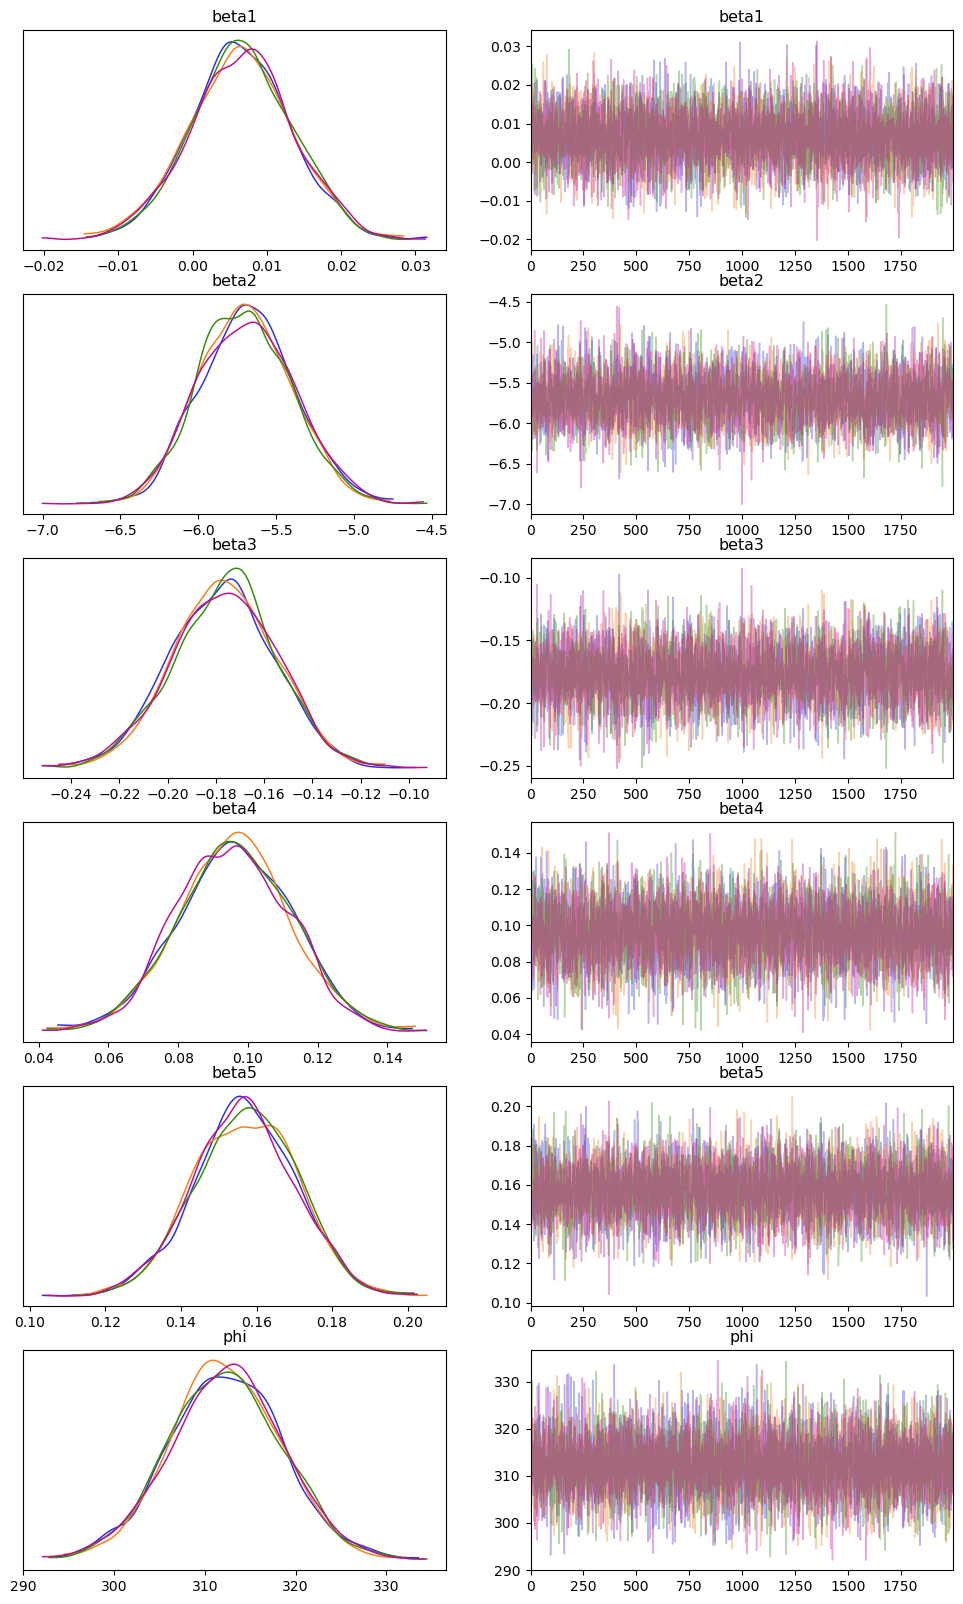

In [119]:
# Posterior plots
az.plot_trace(idata, var_names=["beta1", "beta2", "beta3", "beta4", "beta5", "phi"], compact=False, figsize=(12,20))
plt.savefig('TraceModelWithNormalDist.jpg', dpi=600)

#### Forest Plot

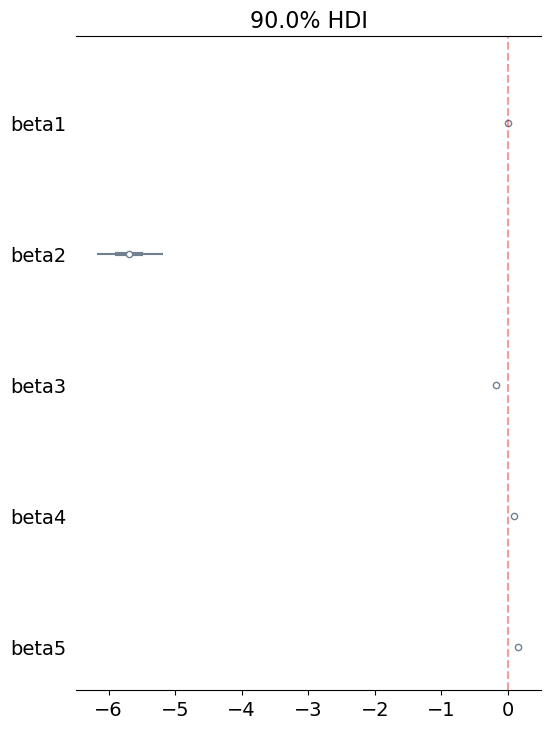

In [121]:
#Forest plot
az.plot_forest(idata, combined=True, colors= 'slategray', var_names= ["beta1", "beta2", "beta3", "beta4", "beta5"], hdi_prob=0.90)
plt.axvline(x=0, c='red', linestyle='--', alpha=0.4)
plt.savefig('ForestPlotNormal.jpg', dpi=600)

# Conclusion

The final model was estimated using weakly informative Normal priors N(0,1) for the regression coefficients rather than Uniform priors U(-1,1). When Uniform(-1,1) priors were employed, the 90% highest density interval for β2 reached the lower boundary of the prior at -1.000, indicating that the prior was artificially truncating the posterior distribution and preventing the data from fully expressing its information about this parameter. This constitutes prior misspecification that biases posterior estimates. In contrast, the Normal prior model produced no boundary violations, achieved R-hat = 1.00 and ESS > 4,000 for all regression coefficients of interest, and is theoretically more appropriate as Normal priors assign smoothly decreasing probability to extreme values rather than imposing hard boundaries, making them the standard weakly informative choice for regression coefficients on the logit scale.

# Extras

Pieces of the last version that are worthy to keep.

### Identifying the 7 divergences

In [406]:
# Identify the problematic 7 observations
diverging = trace.sample_stats.diverging.sum(dim=["chain"])
problem_idx = np.where(diverging.values > 0)[0]

print(f"Diverging observations: {problem_idx}")
print(f"\ny values: {y[problem_idx]}")
print(f"Year: {year[problem_idx]}")
print(f"IDH: {idh[problem_idx]}")
print(f"PIB_cap: {pib_cap[problem_idx]}")
print(f"Area: {area[problem_idx]}")
print(f"Dens_dem: {dens_dem[problem_idx]}")

# Check if these are extreme values
print(f"\nAre these y-boundary values?")
print(f"y < 0.001: {(y[problem_idx] < 0.001).sum()}")
print(f"y > 0.999: {(y[problem_idx] > 0.999).sum()}")

Diverging observations: [ 510  535  586 1060 1523 1739 1874]

y values: [0.00281643 0.00140499 0.00180487 0.00130634 0.00471989 0.00391965
 0.00232323]
Year: [2019 2019 2019 2020 2021 2021 2021]
IDH: [0.728 0.757 0.769 0.769 0.761 0.703 0.704]
PIB_cap: [35584.82438701 33916.16906685 34588.58325939 30658.20950359
 17846.91155346 22903.87065164 20278.96586644]
Area: [ 272.692 1308.432   20.388  108.817  129.367  265.689  368.604]
Dens_dem: [2.21348628e+01 6.52766059e+00 1.45932902e+04 4.50223770e+02
 3.76680297e+01 3.84095691e+01 4.55420994e+01]

Are these y-boundary values?
y < 0.001: 0
y > 0.999: 0


# Compositional Model

This section is gonna be dedicated to preform a Bayesian approach to compositional data.

In [17]:
#Prepare outcome variables 
#Add small constant to avoid log(0)
y1 = np.log((df['fatal/total'].values + 0.000001) / (df['nao disp/total'].values + 0.000001))
y2 = np.log((df['grave/total'].values + 0.000001) / (df['nao disp/total'].values + 0.000001))
y3 = np.log((df['leve/total'].values + 0.000001) / (df['nao disp/total'].values + 0.000001))

In [19]:
#Predictors/covariates
N = len(df)
year = np.array(df.ano - 2018)
pib_cap = df['PIB per capita'].to_numpy()
area = df['area km**2'].to_numpy()
dens = df['dens dem 2021'].to_numpy()
idh = df['IDH municipal'].to_numpy()

#Standirize dens
#dens = (dens - dens.mean())/dens.std()
log_dens_std = (np.log(dens) - np.log(dens).mean()) / np.log(dens).std()

In [61]:
#Bayesian Model
with pm.Model() as compositional_model:

    # Priors for y1 (fatal)
    # OpenBUGS: dnorm(0, 0.01) → precision=0.01 → sigma=sqrt(1/0.01)=10
    beta_year_y1 = pm.Normal('beta_year_y1', mu=0, sigma=10)
    beta_idh_y1 = pm.Normal('beta_idh_y1', mu=0, sigma=10)
    beta_pib_y1 = pm.Normal('beta_pib_y1', mu=0, sigma=10)
    beta_area_y1 = pm.Normal('beta_area_y1', mu=0, sigma=10)
    beta_dens_y1 = pm.Normal('beta_dens_y1', mu=0, sigma=10)

    # Priors for y2 (grave)
    beta_year_y2 = pm.Normal('beta_year_y2', mu=0, sigma=10)
    beta_idh_y2 = pm.Normal('beta_idh_y2', mu=0, sigma=10)
    beta_pib_y2 = pm.Normal('beta_pib_y2', mu=0, sigma=10)
    beta_area_y2 = pm.Normal('beta_area_y2', mu=0, sigma=10)
    beta_dens_y2 = pm.Normal('beta_dens_y2', mu=0, sigma=10)

    # Priors for y3 (leve)
    beta_year_y3 = pm.Normal('beta_year_y3', mu=0, sigma=10)
    beta_idh_y3 = pm.Normal('beta_idh_y3', mu=0, sigma=10)
    beta_pib_y3 = pm.Normal('beta_pib_y3', mu=0, sigma=10)
    beta_area_y3 = pm.Normal('beta_area_y3', mu=0, sigma=10)
    beta_dens_y3 = pm.Normal('beta_dens_y3', mu=0, sigma=10)


    #Precision priors
    tau1 = pm.Gamma('tau1', alpha=1, beta=1)
    tau2 = pm.Gamma('tau2', alpha=1, beta=1)
    tau3 = pm.Gamma('tau3', alpha=1, beta=1)

    #Convert precision to sigma
    sigma1 = pm.Deterministic('sigma1', 1.0/pm.math.sqrt(tau1))
    sigma2 = pm.Deterministic('sigma2', 1.0/pm.math.sqrt(tau2))
    sigma3 = pm.Deterministic('sigma3', 1.0/pm.math.sqrt(tau3))


    #Linear predictors
    mu1 = (beta_year_y1 * year + beta_idh_y1 * idh 
          + beta_pib_y1 * np.log(pib_cap) + beta_area_y1 * np.log(area)
          + beta_dens_y1 * log_dens_std)

    mu2 = (beta_year_y2 * year + beta_idh_y2 * idh 
          + beta_pib_y2 * np.log(pib_cap) + beta_area_y2 * np.log(area)
          + beta_dens_y2 * log_dens_std)

    mu3 = (beta_year_y3 * year + beta_idh_y3 * idh 
          + beta_pib_y3 * np.log(pib_cap) + beta_area_y3 * np.log(area)
          + beta_dens_y3 * log_dens_std)

    #Likelihood
    y1_obs = pm.Normal('y1_obs', mu = mu1, sigma = sigma1, observed = y1)
    y2_obs = pm.Normal('y2_obs', mu = mu2, sigma = sigma2, observed = y2)
    y3_obs = pm.Normal('y3_obs', mu = mu3, sigma = sigma3, observed = y3)

    #Sampling
    comp_model_trace = pm.sample(2000, tune= 2000, target_accept = 0.9, return_inferencedata= True, idata_kwargs= {'log_likelihood' : True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_year_y1, beta_idh_y1, beta_pib_y1, beta_area_y1, beta_dens_y1, beta_year_y2, beta_idh_y2, beta_pib_y2, beta_area_y2, beta_dens_y2, beta_year_y3, beta_idh_y3, beta_pib_y3, beta_area_y3, beta_dens_y3, tau1, tau2, tau3]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 101 seconds.


In [110]:
#Print the summary
sum = az.summary(comp_model_trace)
sum

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_year_y1,0.018,0.052,-0.080,0.115,0.000,0.001,14601.0,5727.0,1.0
beta_idh_y1,-7.098,2.241,-11.093,-2.734,0.028,0.020,6573.0,4926.0,1.0
beta_pib_y1,0.542,0.154,0.246,0.819,0.002,0.001,6839.0,6098.0,1.0
beta_area_y1,0.069,0.113,-0.146,0.282,0.001,0.001,11374.0,5844.0,1.0
beta_dens_y1,-0.830,0.099,-1.007,-0.639,0.001,0.001,10959.0,6570.0,1.0
beta_year_y2,0.069,0.053,-0.034,0.165,0.000,0.000,13332.0,5740.0,1.0
beta_idh_y2,4.330,2.323,0.228,8.834,0.030,0.022,5982.0,5403.0,1.0
beta_pib_y2,0.131,0.161,-0.165,0.437,0.002,0.002,6383.0,5818.0,1.0
beta_area_y2,-0.409,0.118,-0.629,-0.189,0.001,0.001,9695.0,6563.0,1.0
beta_dens_y2,-1.492,0.106,-1.687,-1.292,0.001,0.001,9292.0,5992.0,1.0


### Extracting relevant features

In [138]:
#Extracting relevant features
index = []
for i in range(0,len(sum)):
    if not (sum['hdi_3%'][i] < 0) & (sum['hdi_97%'][i] > 0):
        index.append(i)
sum.iloc[index, :]

/var/folders/t4/0ysr6j1n08q2nnfdfqrmrj7h0000gn/T/ipykernel_4934/397883741.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if not (sum['hdi_3%'][i] < 0) & (sum['hdi_97%'][i] > 0):


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_idh_y1,-7.098,2.241,-11.093,-2.734,0.028,0.020,6573.0,4926.0,1.0
beta_pib_y1,0.542,0.154,0.246,0.819,0.002,0.001,6839.0,6098.0,1.0
beta_dens_y1,-0.830,0.099,-1.007,-0.639,0.001,0.001,10959.0,6570.0,1.0
beta_idh_y2,4.330,2.323,0.228,8.834,0.030,0.022,5982.0,5403.0,1.0
beta_area_y2,-0.409,0.118,-0.629,-0.189,0.001,0.001,9695.0,6563.0,1.0
beta_dens_y2,-1.492,0.106,-1.687,-1.292,0.001,0.001,9292.0,5992.0,1.0
beta_idh_y3,13.995,2.034,10.130,17.756,0.026,0.019,6041.0,5384.0,1.0
beta_pib_y3,0.304,0.139,0.038,0.555,0.002,0.001,6291.0,5522.0,1.0
beta_area_y3,-1.437,0.104,-1.636,-1.248,0.001,0.001,10192.0,6567.0,1.0
beta_dens_y3,-2.751,0.091,-2.915,-2.572,0.001,0.001,10376.0,6522.0,1.0


**Interpretation**
**y1 — Fatal mortality ratio**

- *beta_idh_y1* = -7.098 (HDI: -11.093 to -2.734): Strong negative effect, meaning that municipalities with higher HDI have significantly lower fatal mortality ratios. This result represents the strongest and most intuitive finding, better human development strongly protects against fatal outcomes.
- *beta_pib_y1* = 0.542 (HDI: 0.246 to 0.819): Positive effect meaning that higher PIB per capita is associated with higher fatal ratios. This seems counterintuitive but may reflect that wealthier municipalities have better diagnosis and reporting of fatal cases.
- *beta_dens_y1* = -0.830 (HDI: -1.007 to -0.639): Negative effect reflecting that higher population density associated with lower fatal ratios, possibly reflecting better healthcare access in denser areas.

**y2 — Grave (serious) case ratio**

- *beta_idh_y2* = 4.330 (HDI: 0.228 to 8.834): Positive effect, indicating that higher HDI is associated with higher severe ratios. It is good to highlight the wide credible interval suggesting uncertainty, but the effect is clear directionally.
- *beta_area_y2* = -0.409 (HDI: -0.629 to -0.189): Negative effect, larger municipalities have lower severe ratios.
- *beta_dens_y2* = -1.492 (HDI: -1.687 to -1.292): Strong negative effect suggesting that higher density is associated with lower severe ratios.

**y3 — Mild (leve) case ratio:**

- *beta_idh_y3* = 13.995 (HDI: 10.130 to 17.756): Strongest effect in the entire model. The outcome indicates that higher HDI strongly associated with higher mild case ratios. Combined with the negative HDI effect on fatal cases, this tells a coherent story: better developed municipalities tend to have proportionally more mild cases and fewer fatal ones.
- *beta_pib_y3* = 0.304 (HDI: 0.038 to 0.555): Positive but modest effect.
- *beta_area_y3* = -1.437 (HDI: -1.636 to -1.248): Clear negative effect.
- *beta_dens_y3* = -2.751 (HDI: -2.915 to -2.572): Strongest density effect, meaning higher density strongly associated with lower mild case ratios.

### Trace plot

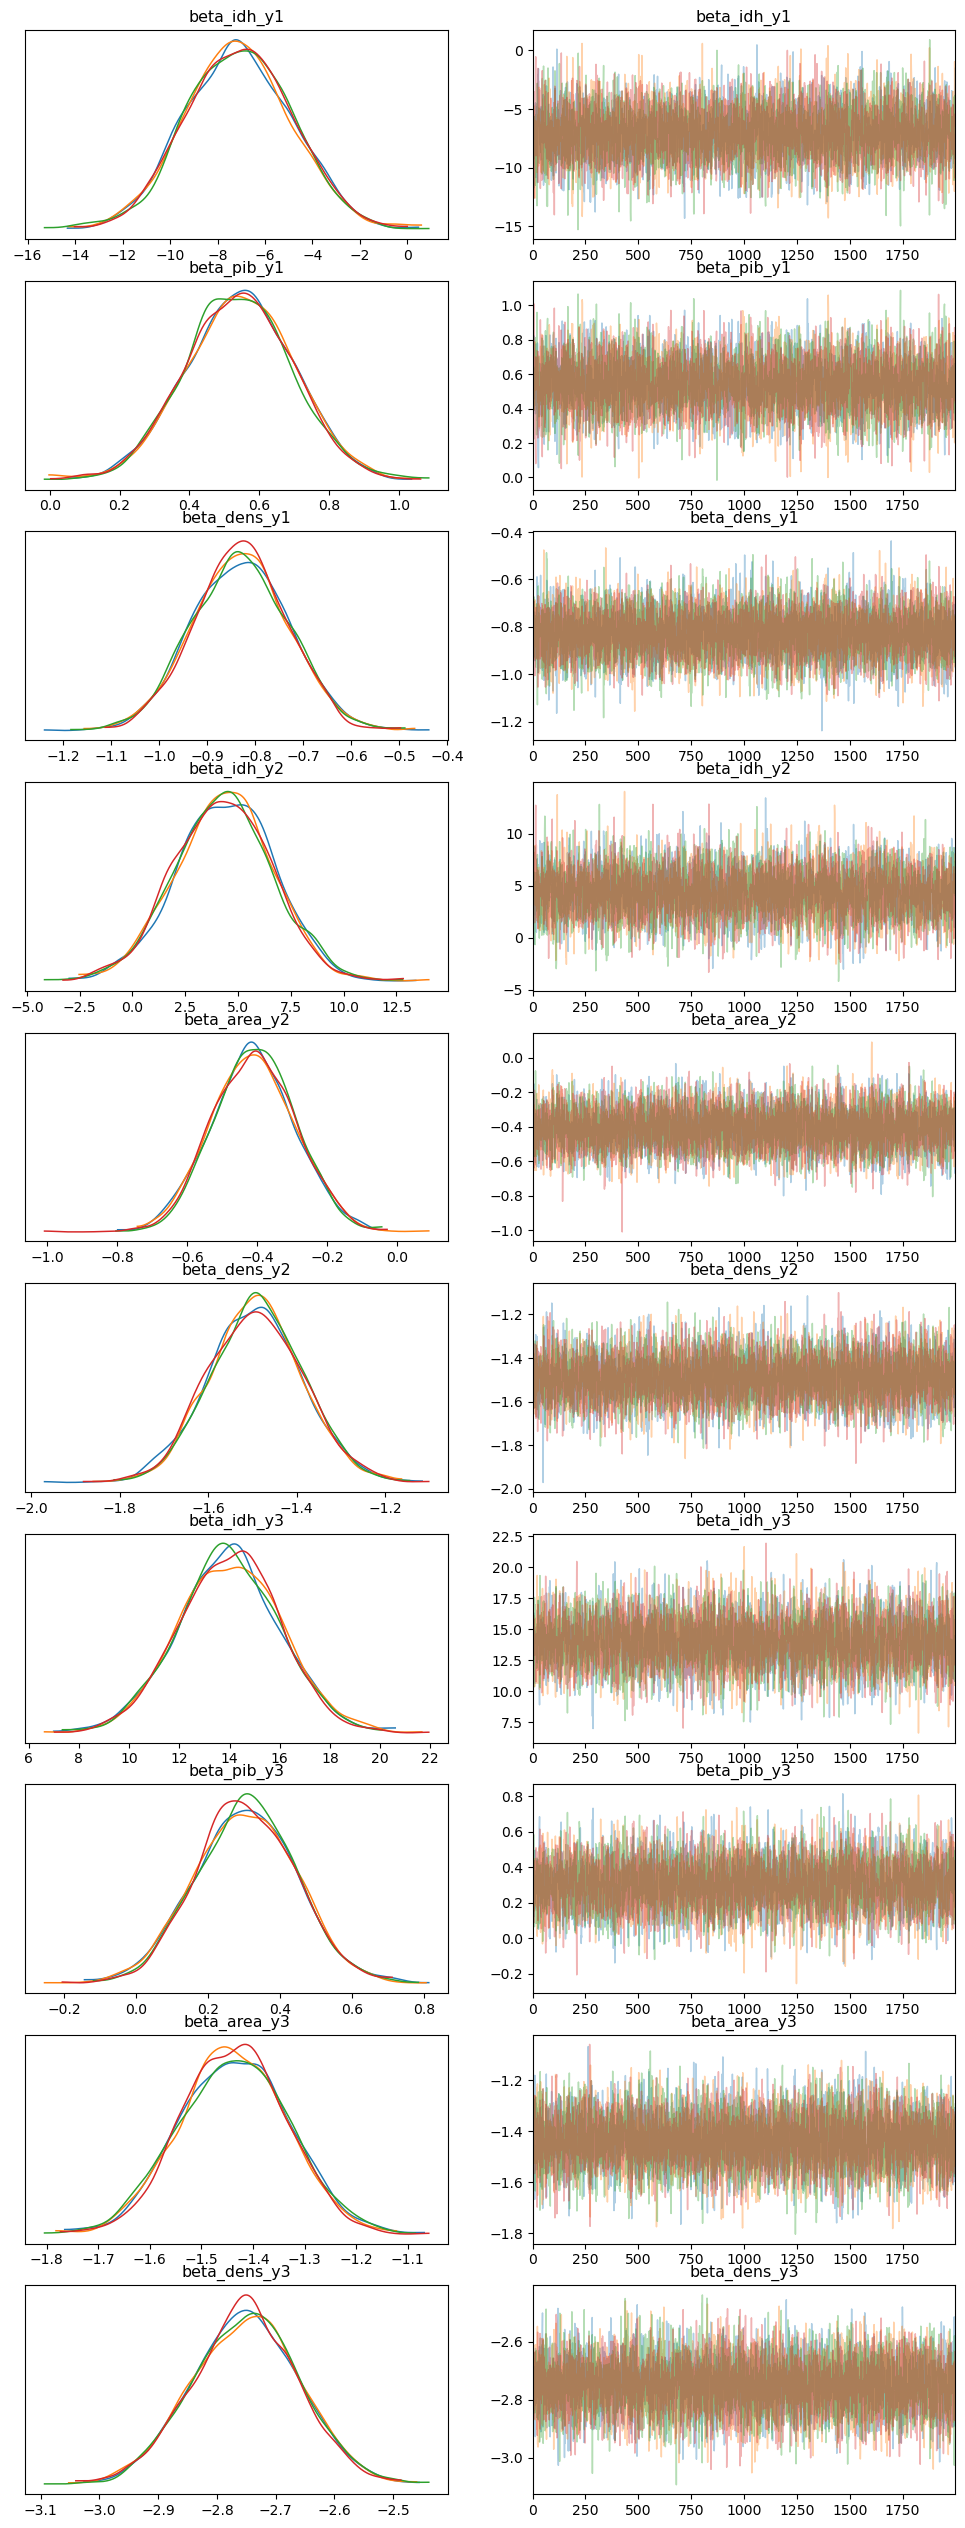

In [169]:
# Posterior plots
az.plot_trace(comp_model_trace, var_names= sum.index[index[0:10]], compact=False, figsize=(12,32))
plt.savefig('CompositionalModelTrace.jpg', dpi=600)

### Forest plot

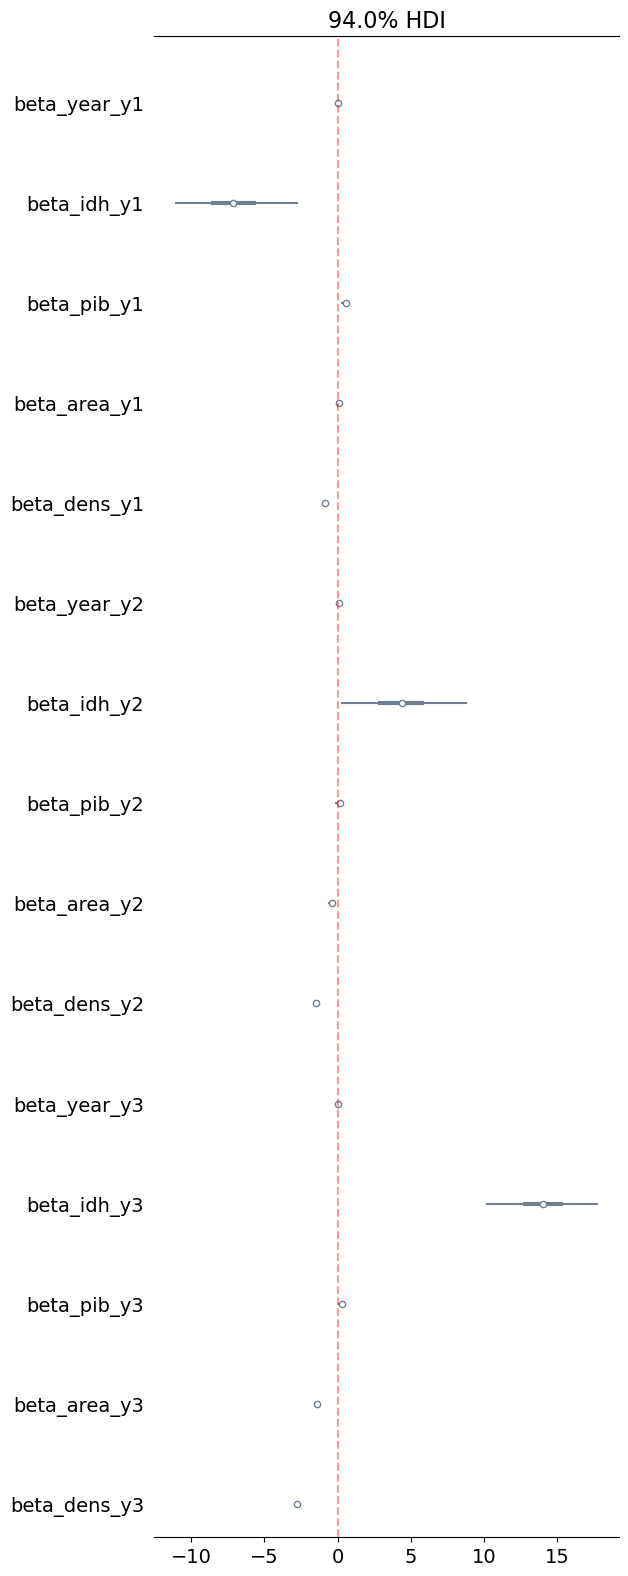

In [181]:
#Forest plot
az.plot_forest(comp_model_trace, combined=True, colors= 'slategray', var_names= sum.index[0:15])
plt.axvline(x=0, c='red', linestyle='--', alpha=0.4)
plt.savefig('ForestPlotCompositionalM.jpg', bbox_inches = 'tight', dpi=600)

# Extras

While developing the model I struggled with struggling with some outcomes, these pieces of code help me solving the problem. This part is not relevant for the model analysis.

In [ ]:
import numpy as np

# Check for problematic values in the log ratios
print("=== y1 (fatal) ===")
print(f"NaN count: {np.sum(np.isnan(y1))}")
print(f"Inf count: {np.sum(np.isinf(y1))}")
print(f"Min: {np.nanmin(y1):.4f}, Max: {np.nanmax(y1):.4f}")

print("\n=== y2 (grave) ===")
print(f"NaN count: {np.sum(np.isnan(y2))}")
print(f"Inf count: {np.sum(np.isinf(y2))}")
print(f"Min: {np.nanmin(y2):.4f}, Max: {np.nanmax(y2):.4f}")

print("\n=== y3 (leve) ===")
print(f"NaN count: {np.sum(np.isnan(y3))}")
print(f"Inf count: {np.sum(np.isinf(y3))}")
print(f"Min: {np.nanmin(y3):.4f}, Max: {np.nanmax(y3):.4f}")

# Also check the raw input variables
print("\n=== Raw inputs ===")
print(f"naodisp_total zeros: {np.sum(df['nao disp/total'] == 0)}")
print(f"fatal_total zeros: {np.sum(df['fatal/total'] == 0)}")
print(f"grave_total zeros: {np.sum(df['grave/total'] == 0)}")
print(f"leve_total zeros: {np.sum(df['leve/total'] == 0)}")

print(f"\nnaodisp_total NaN: {np.sum(np.isnan(df['nao disp/total']))}")
print(f"fatal_total NaN: {np.sum(np.isnan(df['fatal/total']))}")
print(f"grave_total NaN: {np.sum(np.isnan(df['grave/total']))}")
print(f"leve_total NaN: {np.sum(np.isnan(df['leve/total']))}")

In [ ]:
import numpy as np

covariates = {
    'ano_c':        df.ano - 2018,
    'IDH':          df['IDH municipal'],
    'log_PIB':      np.log(df['PIB per capita']),
    'log_area':     np.log(df['area km**2']),
    'log_dens':     np.log(df['dens dem 2021'])
}

for name, cov in covariates.items():
    print(f"=== {name} ===")
    print(f"NaN count: {np.sum(np.isnan(cov))}")
    print(f"Inf count: {np.sum(np.isinf(cov))}")
    print(f"Min: {np.nanmin(cov):.4f}, Max: {np.nanmax(cov):.4f}")
    print()

In [ ]:
print(f"PIBpercapita zeros or negative: {np.sum(pib_cap <= 0)}")
print(f"area zeros or negative: {np.sum(area <= 0)}")
print(f"dens_dem zeros or negative: {np.sum(dens <= 0)}") 

In [ ]:
# First investigate what values are causing the problem
print(f"Zero values: {np.sum(dens == 0)}")
print(f"Negative values: {np.sum(dens < 0)}")
print(f"Unique problematic values: {np.unique(dens[dens <= 0])}")

# Generating Charts

## Bar chart

### Injury gravity

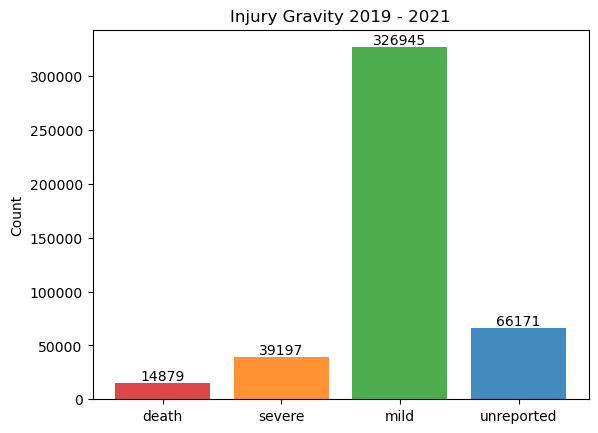

In [112]:
#Create bar chart from 2019 to 2021

#Create the labels 
labels = [df.columns[1:5]] #Labels is a np.array with one item containing all the labels, all the labels are containing as one item inside the array

#Count
count = []
for i in labels[0]: #We access to the only item the array has 
    count.append(sum(df[i][df['ano'] < 2022]))
    #df[df['ano'] < 2022].loc[:,i] An alternative for the process in the parenthesis

#If you want to count the number of rows per year:
#df['grave'][df['ano'] < 2022].count()

#Change the labels to english
lab= ['death', 'severe', 'mild', 'unreported']

#Graph the Bar chart
bar_chart = plt.bar(x= lab, height= count, color= ['tab:red', 'tab:orange', 'tab:green', 'tab:blue'], alpha = 0.85)
plt.bar_label(container= bar_chart, labels= count, label_type='edge') #Add count at the top of the bars
plt.ylabel('Count')
plt.title('Injury Gravity 2019 - 2021')
plt.savefig('InjuryGrav19-21.jpg', dpi=600, bbox_inches = 'tight')
plt.show()

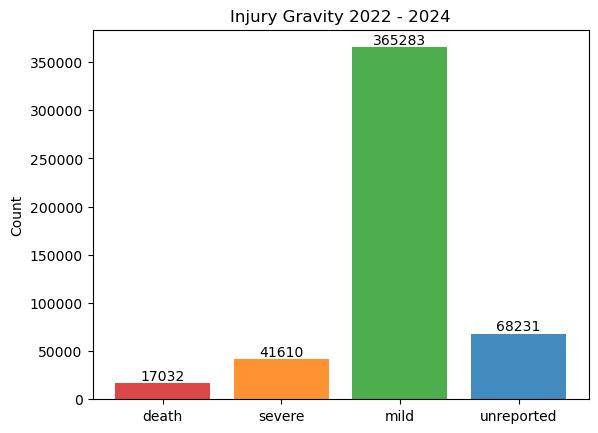

In [131]:
#Bar chart from 2022 to 2024

#Count
count = []
for i in labels[0]: #We access to the only item the array has 
    count.append(sum(df[df['ano']>2021].loc[:,i]))
    #df[df['ano'] < 2022].loc[:,i] An alternative for the process in the parenthesis

#If you want to count the number of rows per year:
#df['grave'][df['ano'] < 2022].count()

#Change the labels to english
lab= ['death', 'severe', 'mild', 'unreported']

#Graph the Bar chart
bar_chart = plt.bar(x= lab, height= count, color= ['tab:red', 'tab:orange', 'tab:green', 'tab:blue'], alpha = 0.85)
plt.bar_label(container= bar_chart, labels= count, label_type='edge') #Add count at the top of the bars
plt.ylabel('Count')
plt.title('Injury Gravity 2022 - 2024')
plt.savefig('InjuryGrav22-24.jpg', dpi=600, bbox_inches = 'tight')
plt.show()

## Road Type

### 2015 - 2021

In [3]:
#Retrieve data from Google Drive

#Set authentification and drive
auth= GoogleAuth()
#auth.LocalWebserverAuth()
drive= GoogleDrive(auth)

#Extract datase from Google Drive
file= drive.ListFile({'q': "title= 'pessoas 2015-2021 (1).csv' and trashed=false"}).GetList()
for file_ in file:
    print('Title: %s, id= %s' % (file_['title'], file_['id']))

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?client_id=1036185829078-4ehal5k5u105gjb9i95beo69q33l9n33.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8080%2F&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive&access_type=offline&response_type=code

Authentication successful.
Title: pessoas 2015-2021 (1).csv, id= 1PE_uR8S997EYIc5nBeD1YSLd-3HN5QBU


In [11]:
#Create the dataframe

#Get the id and create the file to convert it later on a dataframe
id = file[0]['id']
file_= drive.CreateFile({'id':id})
file_.GetContentFile('pessoas 2015-2021 (1).csv')

#Convert excel to pd dataframe
data_15= pd.read_csv('pessoas 2015-2021 (1).csv')
#Print the first row
data_15.head(1)

,id_sinistro,municipio,tipo_via,tipo_veiculo_vitima,sexo,idade,data_obito,gravidade_lesao,tipo_de vítima,faixa_etaria_demografica,...,profissao,data_sinistro,ano_sinistro,mes_sinistro,dia_sinistro,ano_mes_sinistro,ano_obito,mes_obito,dia_obito,ano_mes_obito
0,2463323,SAO PAULO,VIAS MUNICIPAIS,PEDESTRE,MASCULINO,51.0,01/01/2015,FATAL,PEDESTRE,50 a 54,...,NaN,01/01/2015,2015,1,1,2015/01,2015.0,1.0,1.0,2015/01


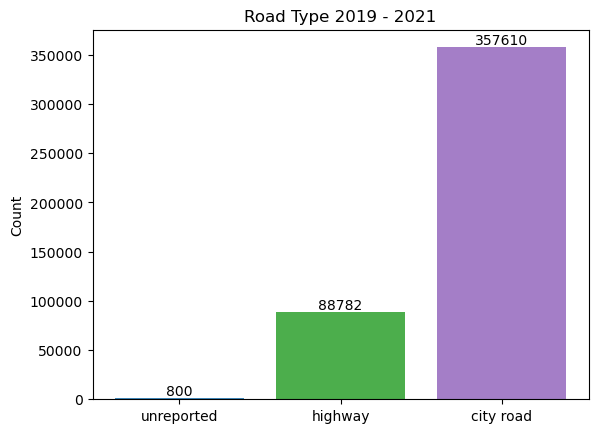

In [39]:
#Plot bar chart

#Labels
lab_15 = list(set(data_15['tipo_via']))

#Count
count_15 = []
for i in lab_15:
    count_15.append(data_15[data_15['ano_sinistro'] > 2018]['tipo_via'][data_15['tipo_via'] == i].count())
    #data_15['tipo_via'][data_15['tipo_via'] == 'VIAS MUNICIPAIS'].count()
count_15

#Change labels to english
labs = ['unreported', 'highway', 'city road']

#Creat bar chart
bar_15 = plt.bar(x= labs, height= count_15, color= ['tab:blue', 'tab:green', 'tab:purple'], alpha= 0.85)
plt.bar_label(container= bar_15, labels= count_15, label_type='edge')
plt.ylabel('Count')
plt.title('Road Type 2019 - 2021')
plt.savefig('RoadT15.jpg', dpi=600, bbox_inches= 'tight')
plt.show()

### 2022 - 2024

In [14]:
#Retrieve data from Google Drive

#Set authentification and drive
auth= GoogleAuth()
#auth.LocalWebserverAuth()
drive= GoogleDrive(auth)

#Extract datase from Google Drive
file= drive.ListFile({'q': "title= 'pessoas 2022-2025 (1).csv' and trashed=false"}).GetList()
for file_ in file:
    print('Title: %s, id= %s' % (file_['title'], file_['id']))

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?client_id=1036185829078-4ehal5k5u105gjb9i95beo69q33l9n33.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8080%2F&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive&access_type=offline&response_type=code

Authentication successful.
Title: pessoas 2022-2025 (1).csv, id= 1GfmGj3DJt5uUdye6wY7lURsKYTL9mcy-


In [233]:
#Create the dataframe

#Get the id and create the file to convert it later on a dataframe
id = file[0]['id']
file_= drive.CreateFile({'id':id})
file_.GetContentFile('pessoas 2022-2025 (1).csv')

#Convert excel to pd dataframe
data_22= pd.read_csv('pessoas 2022-2025 (1).csv')
#Print the first row
data_22.head(1)

,id_sinistro,municipio,tipo_via,tipo_veiculo_vitima,sexo,idade,data_obito,gravidade_lesao,tipo_de vítima,faixa_etaria_demografica,...,profissao,data_sinistro,ano_sinistro,mes_sinistro,dia_sinistro,ano_mes_sinistro,ano_obito,mes_obito,dia_obito,ano_mes_obito
0,1921252,CAMPINAS,VIAS MUNICIPAIS,NaN,MASCULINO,28.0,NaN,LEVE,CONDUTOR,25 a 29,...,AUTONOMO(A),01/01/2022,2022,1,1,2022/01,NaN,NaN,NaN,NaN


In [235]:
#Get rid from information from 2025
data_22 = data_22[data_22['ano_sinistro'] < 2025]

#Check the years
set(data_22['ano_sinistro'])

{2022, 2023, 2024}

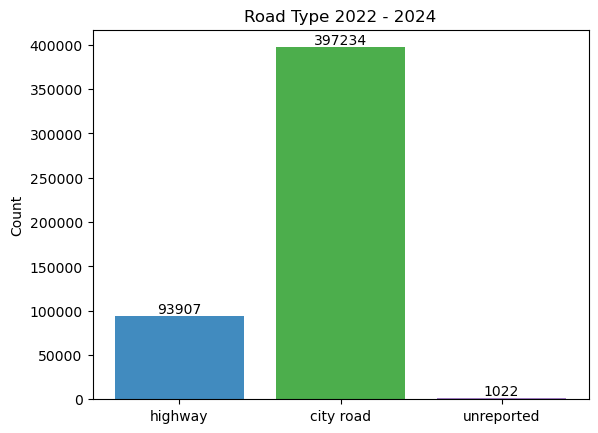

In [245]:
#Plot bar chart

#Labels
lab_22 = list(set(data_22['tipo_via']))

#Count
count_22 = []
for i in lab_22:
    count_22.append(data_22['tipo_via'][data_22['tipo_via'] == i].count())
    #data_15['tipo_via'][data_15['tipo_via'] == 'VIAS MUNICIPAIS'].count()

#Change labels to english
labs_22 = ['highway', 'city road', 'unreported']

#Creat bar chart
bar_22= plt.bar(x= labs_22, height= count_22, color= ['tab:blue', 'tab:green', 'tab:purple'], alpha= 0.85)
plt.bar_label(container= bar_22, labels= count_22, label_type='edge')
plt.ylabel('Count')
plt.title('Road Type 2022 - 2024')
plt.savefig('RoadT22.jpg', dpi=600, bbox_inches= 'tight')
plt.show()

# Confidence Intervals 2019 - 2024

In this section we are gonna plot the CI of the first dataset.

In [73]:
#Import needed libraries
import scipy.stats as stats

#create a function to plot all the CI graphs

def ci_plots(df, column, column_eng):

    #Variables
    years = sorted(df['ano'].unique())
    #Alternative: list(set(df['ano']))
    means = []
    ci_lower = []
    ci_upper = []

    #Compute the 95% CI
    for i in years:
        values = df[column][df.ano == i].values
        n = len(values)
        mean = np.mean(values)
        se = stats.sem(values)
        ci = stats.t.ppf(0.97, df= n-1) * se

        means.append(mean)
        ci_lower.append(mean - ci)
        ci_upper.append(mean + ci)

    #Plot the graph
    plt.errorbar(years, means, yerr= [np.array(means) - np.array(ci_lower),
                                    np.array(ci_upper) - np.array(means)],
                fmt= 'o', color= 'black', ecolor='green', capsize= 8)
    plt.xlabel('Year')
    plt.ylabel(column_eng)
    plt.title('95% CI for the mean rate')
    fig_name= column_eng[0:4] + '.jpg'
    plt.savefig(fig_name, dpi=600, bbox_inches='tight')
    plt.show()

In [299]:
#Get the columns and the position of each 
for i,j in enumerate (df.columns):
    print('Column: %s, Position: %s' % (i,j))

Column: 0, Position: municipio SP
Column: 1, Position: fatal
Column: 2, Position: grave
Column: 3, Position: leve
Column: 4, Position: não dispon
Column: 5, Position: total
Column: 6, Position: ano
Column: 7, Position: pop 2021
Column: 8, Position: total/pop
Column: 9, Position: fatal/total
Column: 10, Position: grave/total
Column: 11, Position: leve/total
Column: 12, Position: IDH municipal
Column: 13, Position: IDH renda
Column: 14, Position: IDH longevidade
Column: 15, Position: IDH educação
Column: 16, Position: PIB municipal em milhares -2020
Column: 17, Position: PIB per capita
Column: 18, Position: area km**2
Column: 19, Position: dens dem 2021
Column: 20, Position: logit(total/pop)
Column: 21, Position: logit(fatal/total)
Column: 22, Position: logit(grave/total)
Column: 23, Position: logit(leve/total)
Column: 24, Position: PIB/100000
Column: 25, Position: PIB.cap/1000
Column: 26, Position: fatal/total_1
Column: 27, Position: grave/total_1
Column: 28, Position: leve/total_1
Colu

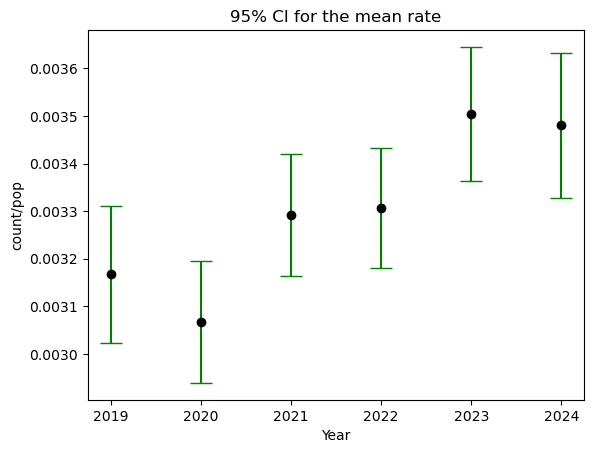

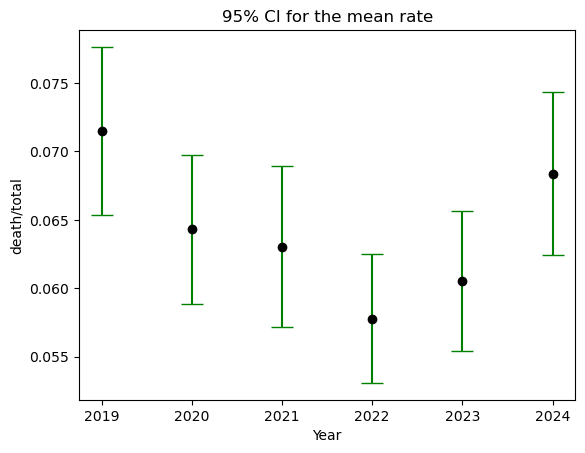

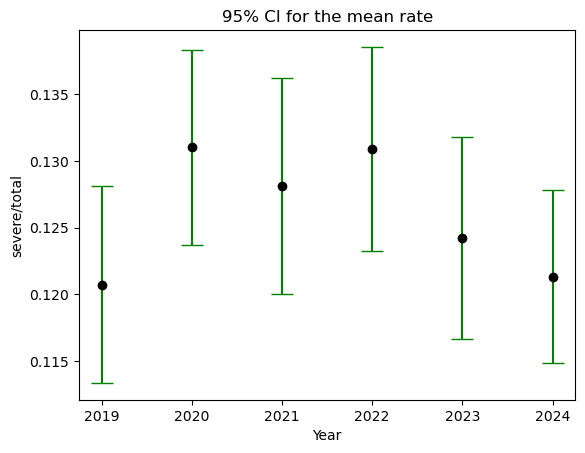

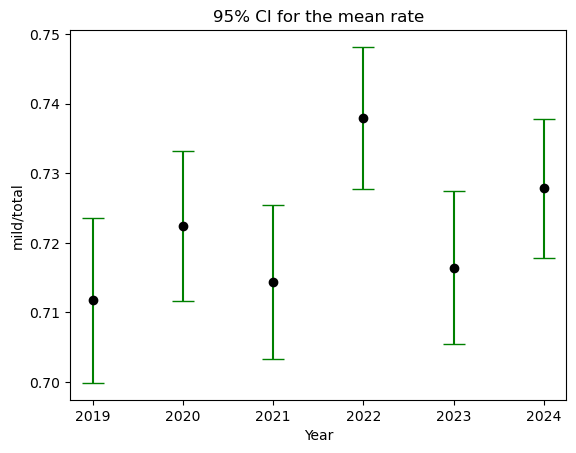

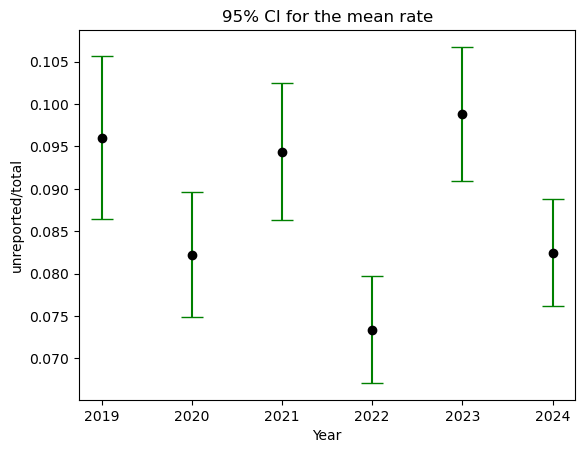

In [75]:
#Get the necessary columns 
columns = df.columns[[8,9,10,11,-1]]
english_col = ['count/pop', 'death/total','severe/total','mild/total','unreported/total']

#Iterate over the values
for i in range(0,len(columns)):
    ci_plots(df=df, column=columns[i], column_eng=english_col[i])